In [1]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.preprocessing import scale
from scipy.interpolate import griddata
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import pandas as pd
import math
from sklearn.decomposition import PCA
import umap

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
file_path = "WVS_Cross-National_Wave_7_csv_v6_0.csv"

wvs = pd.read_csv(file_path)#, low_memory=False)

wvs.columns = wvs.columns.str.upper()

/var/folders/sl/vnf426s55n5b1nyg0gf3qr4r0000gn/T/ipykernel_87848/3349751548.py:3: DtypeWarning: Columns (346,348,350,580,581,582,583) have mixed types. Specify dtype option on import or set low_memory=False.
  wvs = pd.read_csv(file_path)#, low_memory=False)


In [3]:
bad_col = []
for c in wvs.columns:
    for i in range(len(wvs[c])):
        if "str" in str(type(wvs[c][i])):
            #print(c + str(type(wvs[c][i])))
            bad_col.append(c)
            break

In [4]:
clean_wvs = wvs
for c in bad_col:
    clean_wvs = clean_wvs.drop(c, axis=1)

In [5]:
for c in clean_wvs.columns:
    if "str" in str(type(wvs[c][0])):
        print(c + str(type(wvs[c][0])))
        

In [7]:
counts = clean_wvs['B_COUNTRY'].value_counts()
print(counts)

124    4018
360    3200
156    3036
826    2609
840    2596
       ... 
32     1003
858    1000
196    1000
152    1000
909     447
Name: B_COUNTRY, Length: 66, dtype: int64


In [6]:
rom_wvs = clean_wvs[clean_wvs['B_COUNTRY'] == 360].copy()

In [7]:
rom_wvs = rom_wvs.fillna(-1)
child_rearing_questions = [f"Q{i}" for i in range(7, 18)]
moral_questions = [f"Q{i}" for i in range(176, 187)]
selected_questions = child_rearing_questions + moral_questions
existing_questions = [q for q in selected_questions if q in wvs.columns]

X = rom_wvs[existing_questions].to_numpy()
#Y = wvs["Q262"]
Y = rom_wvs["X003R"].to_numpy()

In [8]:
b = []
print(X.shape)
for i in range(X.shape[1]):
    temp = np.corrcoef(Y,X[:,i])[0][1]
    if not np.isnan(temp):
        b.append(np.corrcoef(Y,X[:,i])[0][1])
b = np.array(b)
print(b.max(),b.min(), b.mean())

(3200, 22)
0.11669203980065464 -0.14778996148182538 0.031470151778080296


In [9]:
import scipy
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import PCA
def compare(X,Y):
    comps = 22
    all_cors = []
    pca = PCA(n_components=comps)
    X_pca = pca.fit_transform(X)
    print("PCA's calc'ed")
    p_max_cor = 0
    p_max_cor_ind = 0
    for i in range(comps):
        cor = np.corrcoef(Y,X_pca[:,i])[0,1]
        if abs(p_max_cor) < abs(cor):
            p_max_cor = cor
            p_max_cor_ind = i
    p_sp = scipy.stats.spearmanr(Y, X_pca[:,p_max_cor_ind])
    all_cors.append((p_max_cor, p_sp.statistic, p_sp.pvalue))
    print("PCA stats calc'ed")
    del pca, X_pca
    global umap
    umap_model = umap.UMAP(n_components=comps, n_neighbors=comps,min_dist=0.2,metric='euclidean',random_state=2)
    X_umap = umap_model.fit_transform(X)
    #print(X_umap.shape)
    print("UMAP calc'ed")
    u_max_cor = 0
    u_max_cor_ind = 0
    for i in range(comps):
        cor = np.corrcoef(Y,X_umap[:,i])[0,1]
        if abs(u_max_cor) < abs(cor):
            u_max_cor = cor
            u_max_cor_ind = i
    u_sp = scipy.stats.spearmanr(Y, X_umap[:,u_max_cor_ind])
    all_cors.append((u_max_cor, u_sp.statistic, u_sp.pvalue))
    print("UMAP stats calc'ed")
    del umap, X_umap
    tsne = TSNE(n_components=3, random_state=2, perplexity=30)
    X_tsne = tsne.fit_transform(X)
    print("TSNE calc'ed")
    t_max_cor = 0
    t_max_cor_ind = 0
    for i in range(3):
        cor = np.corrcoef(Y,X_tsne[:,i])[0,1]
        if abs(t_max_cor) < abs(cor):
            t_max_cor = cor
            t_max_cor_ind = i
    t_sp = scipy.stats.spearmanr(Y, X_tsne[:,t_max_cor_ind])
    all_cors.append((t_max_cor, t_sp.statistic, t_sp.pvalue))
    print(all_cors)
    return all_cors
l = compare(X,Y)

PCA's calc'ed
PCA stats calc'ed


/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP calc'ed
UMAP stats calc'ed
TSNE calc'ed
[(0.13006414373848618, 0.08715782920089812, 7.89829729421018e-07), (0.056830289190392916, 0.05036150707050946, 0.0043778064910849936), (0.06285381093525602, 0.05358405674087111, 0.002428055272656343)]


In [12]:
["261","262","X003R","X003R2"]
X.shape

(3200, 22)

In [13]:
SOM_DIM = int(5*X.shape[0]**.54)
print(SOM_DIM)
som = MiniSom(SOM_DIM, SOM_DIM, X.shape[1], sigma=.7,
              learning_rate=0.75, neighborhood_function='triangle')
som.pca_weights_init(X[:int(.1*len(X))])
som.train(X, 500000, random_order=True, verbose=True)

390


/opt/homebrew/lib/python3.11/site-packages/minisom.py:235: UserWarning: sigma should be an integer >=1 when triangle or bubbleare used as neighborhood function
  warn('sigma should be an integer >=1 when triangle or bubble' +
/opt/homebrew/lib/python3.11/site-packages/minisom.py:447: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


 [ 500000 / 500000 ] 100% - 0:00:00 left 
 quantization error: 2.200003299188167


In [14]:
def encode(X):
    vals = {}
    for i in range(len(X)):
        vals[X[i]] = 1
    lb = LabelBinarizer()
    lb.fit(list(vals.keys()))
    return (lb.classes_, vals.keys(), lb.transform(X))

'''
def generate_colors(max_val):
    colors = []
    for i in range(max_val):
        colors.append((np.random.rand(), np.random.rand(), np.random.rand()))
    return colors
'''
label_colors = {
    6: 'red',       
    1: 'blue',      
    2: 'green',     
    0: 'purple',    
    8: 'gray',      
    4: 'orange',    
    5: 'cyan',      
    9: 'magenta',   
    3: 'yellow',    
    7: 'brown',     
    10: 'lime',
    11: 'pink',
    12: 'teal',
    13: 'bisque',
    14: 'tan',
    15: 'black',
    16: 'white',
    17: 'powderblue',
    18: 'rosybrown',
    19: 'peru',
    20: 'deeppink',
    21: 'mediumpurple',
    22: 'plum',
    23: 'deepskyblue',
    24: 'darkseagreen',
    25: 'tomato',
    26: 'cadetblue',
    27: 'beige',
    28: 'navy',
    29: 'palevioletred',
    30: 'gainsboro'}

"""
    make_3d_graph makes a 3d surface map or a 3d point cloud out of the som with 4 sides shown
        * som = self organizing map trained on the dataset 
        * flie = (str) file the data comes from and will be used for the path the figures are saved to
        * X = (cp array) cell counts
        * Y = (np array) cell types
        * surface = (bool) whether or not to plot with the surface or not
"""
def make_3D_graph(som, X, Y, DIM, surface=False):
    classes_lb, labels, Y0 = encode(Y)
    #max_Y0 = Y0.max()
    #label_colors = generate_colors(len(classes_lb)) #max_Y0)
    #for side_view in range(4):
    if 1:
        side_view = 0
        fig = plt.figure(figsize=(50, 50))
        ax = fig.add_subplot(projection='3d')
        x = np.zeros(DIM * DIM).reshape((DIM,DIM))
        y = np.array(list(np.arange(DIM)) * DIM).reshape((DIM,DIM))


        for i in range(DIM):
            x[i,:] = i

        X = np.array(X)
        maps = som.distance_map()
        labels_map = som.labels_map(X, Y)
        if surface: 
            ax.plot_surface(x, y, som.distance_map(),cmap="viridis")

        AZIM = -side_view*90-45
        ax.view_init(elev=30, azim=AZIM, roll=0)

        mapped = 0

        points = np.zeros((Y.shape[0], 4))
        for x in range(DIM):
            for y in range(DIM):
                label_list = labels_map.get((x, y), [])
                if label_list:
                    for label in list(label_list.keys()):
                        index = np.where(classes_lb == label)[0][0]

                        points[mapped] = [x,y,maps[x][y],index]
                        mapped += 1

        for n,l in enumerate(classes_lb):
          mask = (points[:, 3] == n)
          plotters = np.copy(points[mask, :3])
          
          ax.scatter(plotters[:,0],plotters[:,1], plotters[:,2],color = label_colors[n], label=l)   
        ax.legend()

        colors_labels = []
        for n, l in enumerate(classes_lb):
          colors_labels.append([label_colors[n], str(l)])

        counts_lab = np.zeros(len(classes_lb))
        for y in Y0:
          if y.shape[0] <=1:
              index = y
          else:
              index = np.argmax(y)
          counts_lab[index] += 1

        tabled = np.array([np.array(classes_lb), counts_lab.astype(int)]).T
        ax.table(tabled)
        ax.set_xlabel('X coordinate of SOM')
        ax.set_ylabel('Y coordinate of SOM')
        ax.set_zlabel('Node Activation')

        plt.title('SOM with Labels Represented by Colors')
        plt.show("wvs_" + str(SOM_DIM) + ".png")
        return points

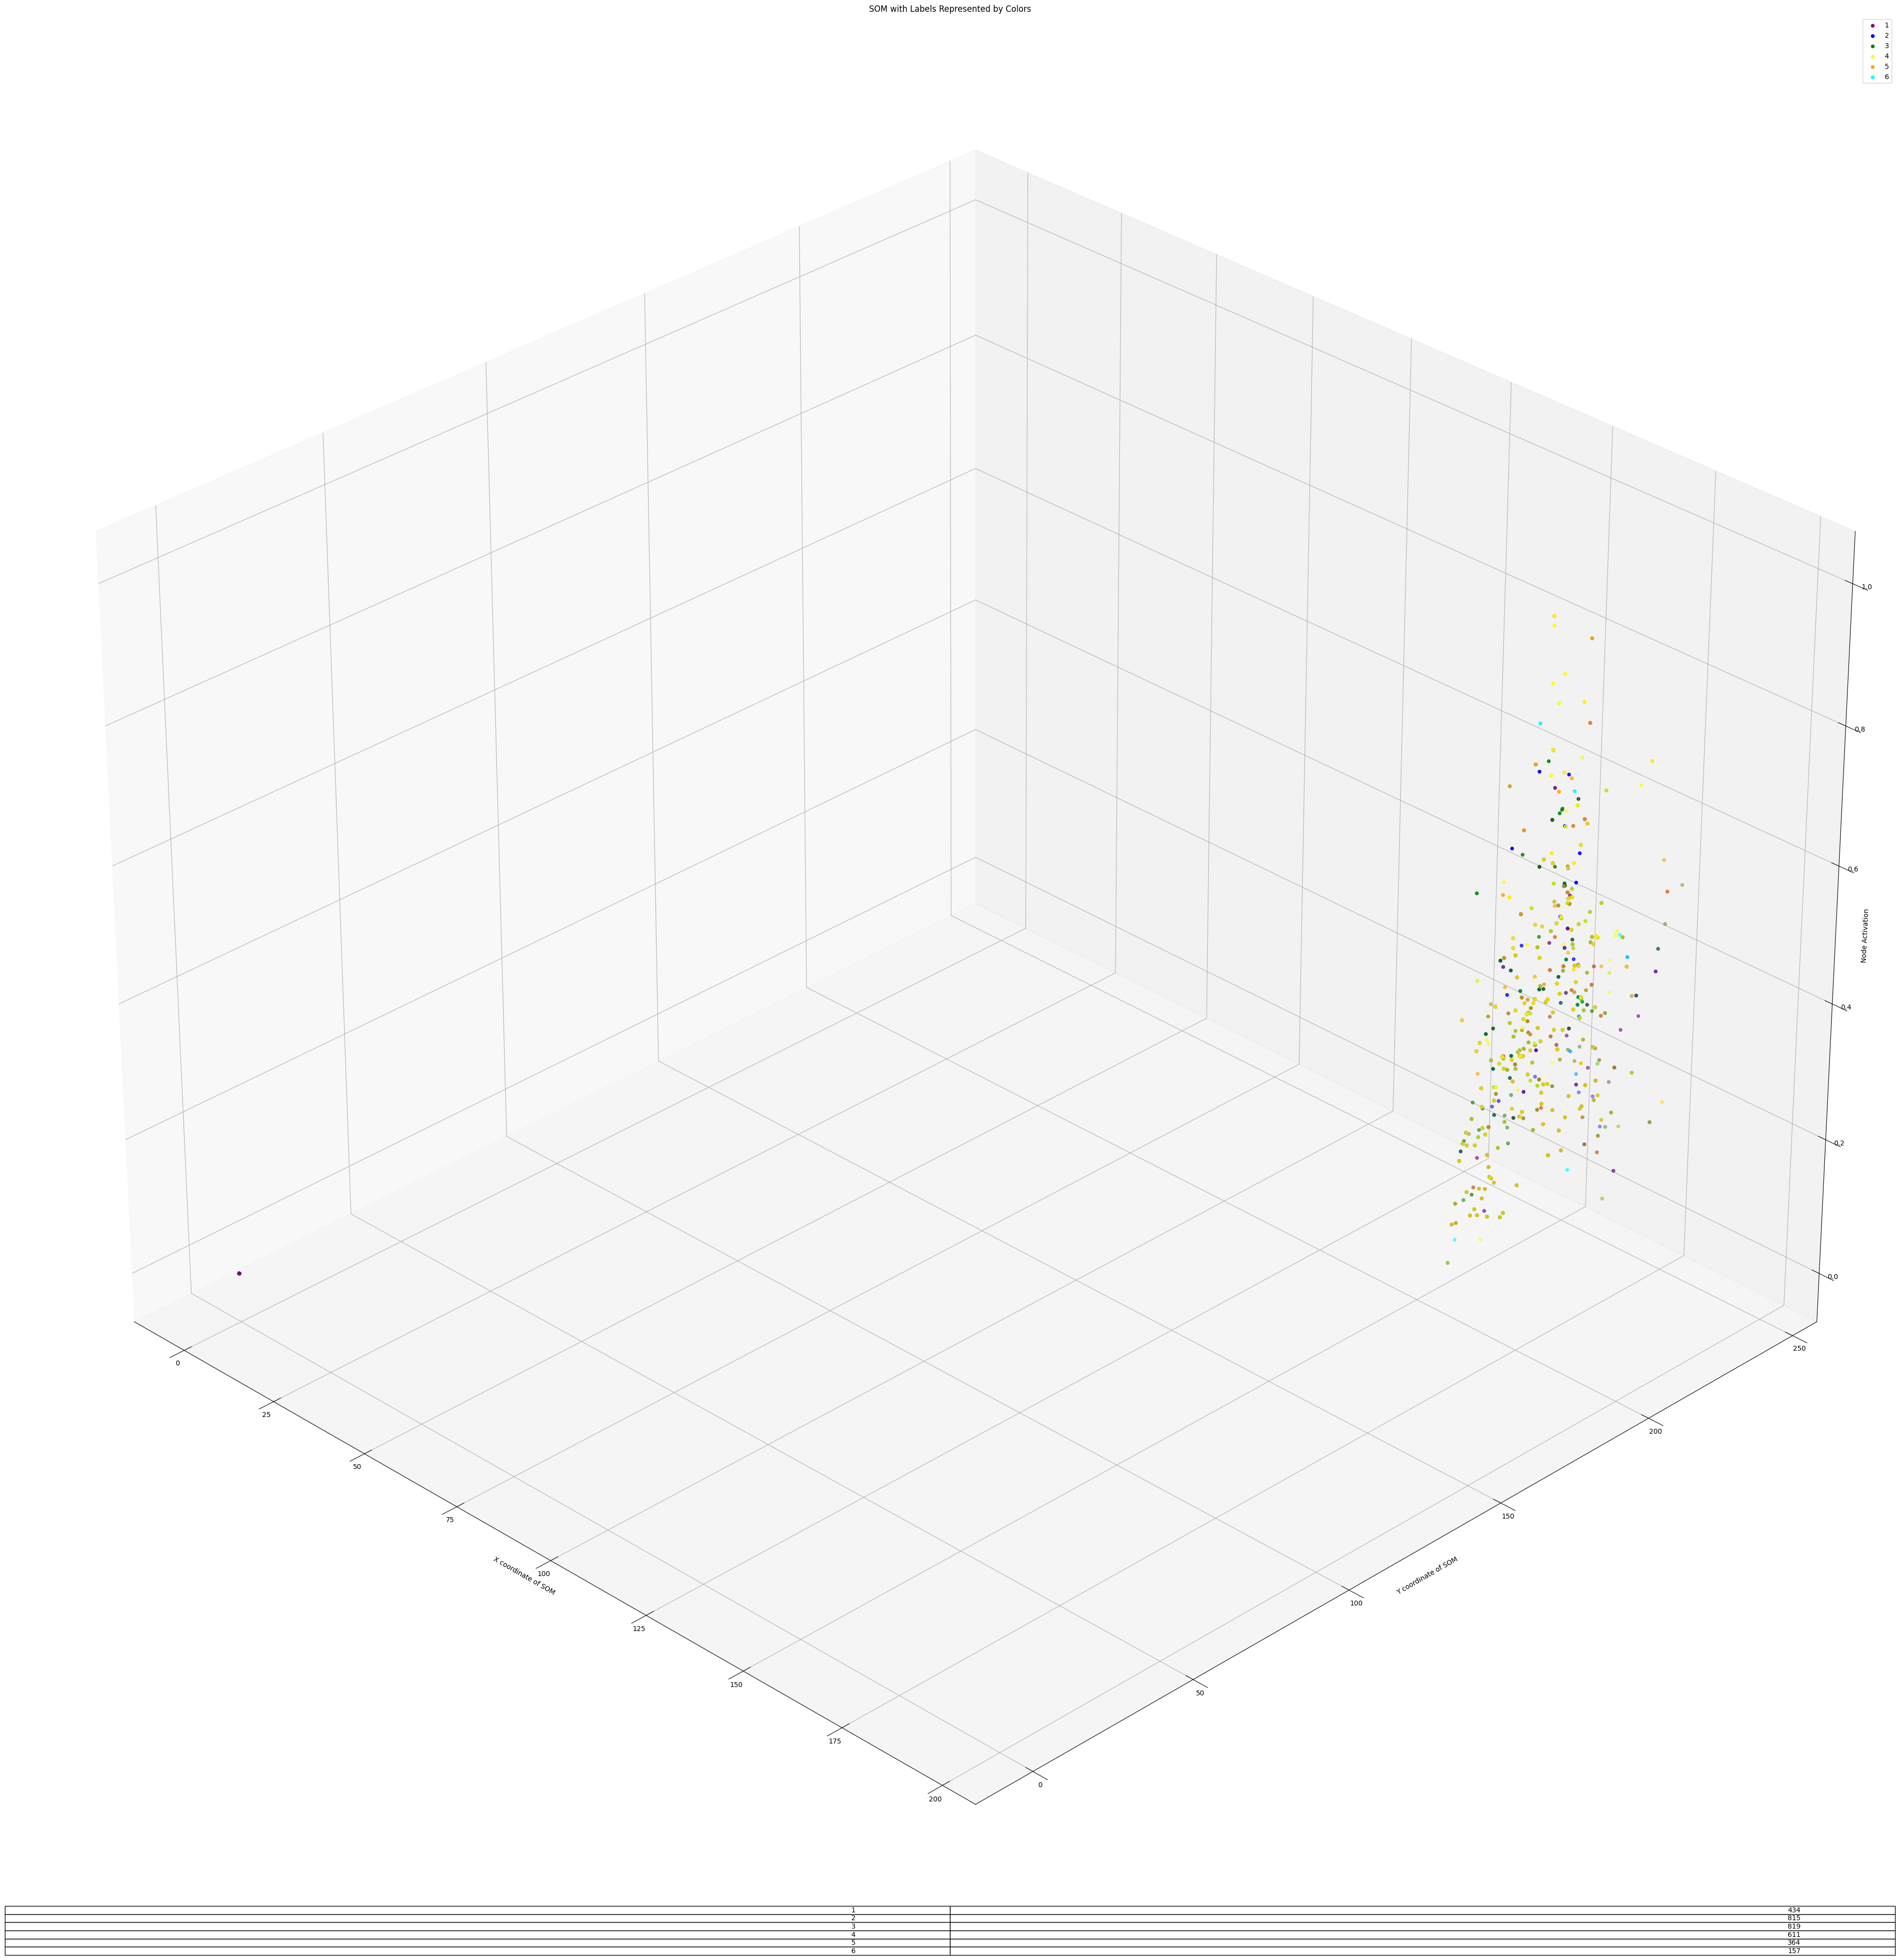

In [15]:
vals = make_3D_graph(som, X, Y, SOM_DIM)

purple 0.0
blue 1.0
green 2.0
yellow 3.0
orange 4.0
cyan 5.0


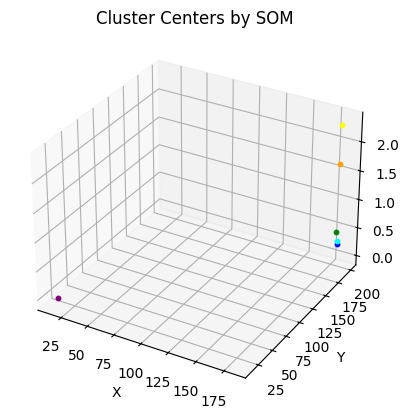

In [29]:
xyz = vals[:, :3]
labels = vals[:, 3]

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)

# ---- Plot ----
fig = plt.figure()
ax = plt.subplot(projection='3d')

# Plot centers
#ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3], s=120, marker='o')

# Annotate each center with its label
idz = centers[:,3].argmax()
label_with_max_z = int(centers[idz, 0])
max_z = centers[idz, 3]
for row in centers:
    #lab, cx, cy, cz = row
    #ax.text(cx, cy, cz, str(int(lab)))
    lab, cx, cy, cz = row
    color = label_colors[int(lab)]
    print(color,lab)
    ax.scatter(cx, cy, cz**50, s=10, color=color)
    ax.text(cx, cy, cz, str(int(lab)))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cluster Centers by SOM")

plt.show()

In [38]:
#Z axis for each group, look at PCA vs age, look at UMAP 
#Figure out how to create divergence (mutliple waves same country) 

np.corrcoef(centers[:,3], centers[:,0])


array([[1.        , 0.66324855],
       [0.66324855, 1.        ]])

In [8]:

pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)


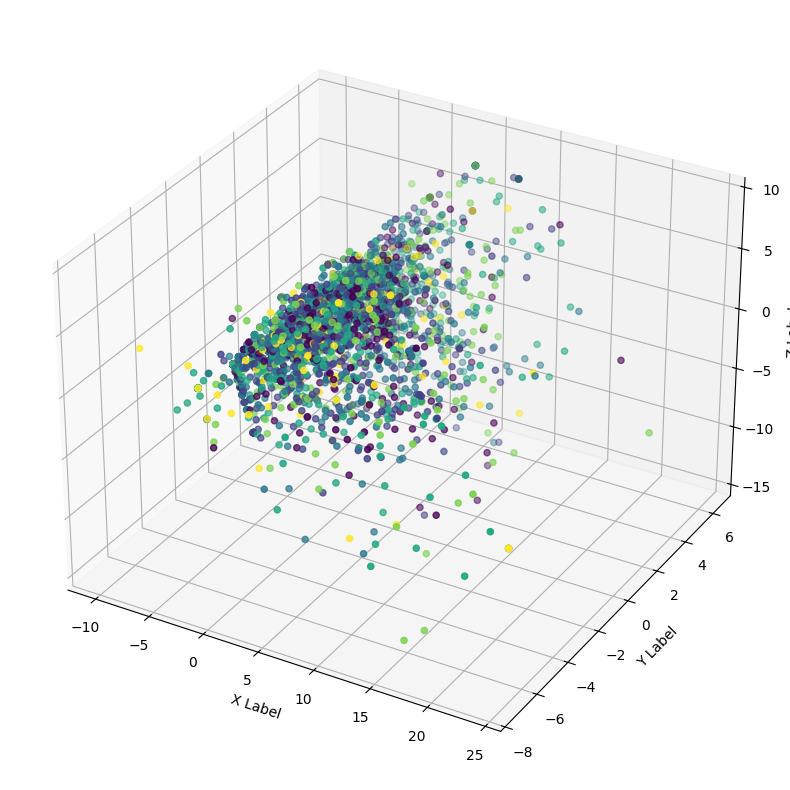

In [24]:
fig1 = plt.figure(figsize=(10, 10))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = Y, marker='o')

# Set labels
ax1.set_xlabel('X Label')
ax1.set_ylabel('Y Label')
ax1.set_zlabel('Z Label')
plt.show()

purple 1.0
blue 2.0
green 3.0
yellow 4.0
orange 5.0
cyan 6.0


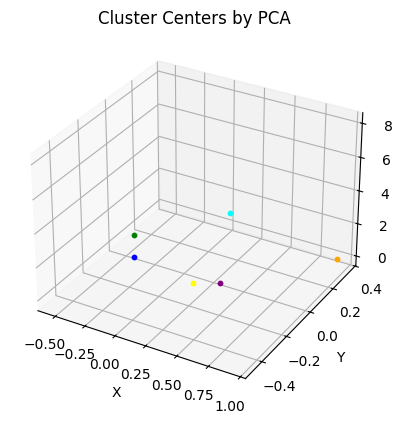

In [28]:
xyz = X_pca[:, :3]
labels = Y

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)

# ---- Plot ----
fig = plt.figure()
ax = plt.subplot(projection='3d')

# Plot centers
#ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3], s=120, marker='o')

# Annotate each center with its label
idz = centers[:,3].argmax()
label_with_max_z = int(centers[idz, 0])
max_z = centers[idz, 3]
for row in centers:
    #lab, cx, cy, cz = row
    #ax.text(cx, cy, cz, str(int(lab)))
    lab, cx, cy, cz = row
    color = label_colors[int(lab) - 1]
    print(color,lab)
    ax.scatter(cx, cy, cz**50, s=10, color=color)
    ax.text(cx, cy, cz, str(int(lab)))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cluster Centers by PCA")

plt.show()

In [11]:
import scipy
cor0 = np.corrcoef(Y,X_pca[:,0])
cor1 = np.corrcoef(Y,X_pca[:,1])
cor2 = np.corrcoef(Y,X_pca[:,2])
cor3 = np.corrcoef(Y,X_pca[:,3])
cor4 = np.corrcoef(Y,X_pca[:,4])

print(cor0[0,1])
print(cor1[0,1])
print(cor2[0,1])
print(cor3[0,1])
print(cor4[0,1])
scipy.stats.spearmanr(Y, X_pca[:,0])

0.06503368017286063
0.004468464900965738
0.02423600744431688
-0.04628885697856298
0.01025109930869872


SignificanceResult(statistic=0.03530768267646657, pvalue=0.04580927297444608)

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


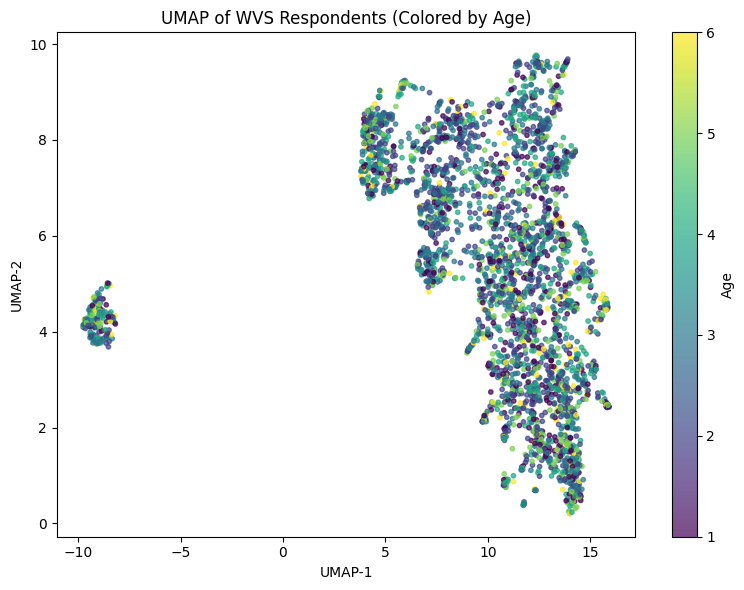

In [12]:

umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.2,
    n_components=2,
    metric='euclidean',
    random_state=42
)

embedding = umap_model.fit_transform(X)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=Y,
    cmap='viridis',
    s=10,
    alpha=0.7
)

plt.colorbar(sc, label='Age')
plt.title('UMAP of WVS Respondents (Colored by Age)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')

plt.tight_layout()
plt.show()


In [14]:
umap_cor0 = np.corrcoef(Y,embedding[:,0])
umap_cor1 = np.corrcoef(Y,embedding[:,1])
print(umap_cor0[0,1],umap_cor1[0,1])
scipy.stats.spearmanr(Y, embedding[:,1])

-0.021296264072278075 -0.06493817347057254


SignificanceResult(statistic=-0.05664782342231852, pvalue=0.0013468422148601358)